# TDMMA Workshop 2026 — Day 1 Practical Session
## Interactive Alert Broker Triage & Spectroscopic Follow-Up Pipeline
 
**Target Telescope:** Las Cumbres Observatory (LCO) 2-Meter Robotic Network (Cerro Tololo, Chile)

---
### Mission Briefing
The Vera C. Rubin Observatory (LSST) and Zwicky Transient Facility (ZTF) produce millions of optical alerts nightly. Let's say thaat someone secured **one 30-minute spectroscopic slot** tonight on the LCO 2-meter telescope. 

The objective is to build a Python pipeline to:
1. Ingest fresh alerts via the **ALeRCE** broker.
2. Calculate photometric metrics ($\Delta m/\Delta t$, color, historical baseline) to filter out AGNs and variable stars.
3. Verify via the **Transient Name Server (TNS)** that the candidate is unclassified.
4. Model telescope airmass constraints and generate an LCO JSON trigger payload.

### Environment Setup & Background Engine

**Instructions:** Run the initialization cells below to load the required astrophysical libraries, local modules, and data environment.

In [1]:
# Standard Data Science & Astronomy Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time

# ALeRCE Python Client
from alerce.core import Alerce

# Local Workshop Modules (CASSA Backend Validation)
import sys
import os
sys.path.append(os.path.abspath('../modules'))

try:
    from observability import cassa_tns_check
    print("[\033[92mSUCCESS\033[0m] Local CASSA modules loaded.")
except ImportError:
    print("[\033[91mERROR\033[0m] Could not load local modules. Ensure you are running this inside the 'notebooks' directory.")

# Initialize the ALeRCE API Client
alerce = Alerce()

[SUCCESS] Local CASSA modules loaded.


In [2]:
USE_LIVE_API = True

if not USE_LIVE_API:
    print("[*] USE_LIVE_API is False. Bypassing live ZTF streams...")
    failsafe_path = os.path.join("..", "data", "reference_alerts.parquet")
    try:
        df_alerts = pd.read_parquet(failsafe_path)
        print(f"[\033[92mSUCCESS\033[0m] Offline Failsafe Loaded: {len(df_alerts)} targets in memory.")
    except Exception as e:
        print(f"[\033[91mERROR\033[0m] Could not load offline data: {e}")
else:
    print("[*] USE_LIVE_API is True. Standing by for live ZTF querying...")

[*] USE_LIVE_API is True. Standing by for live ZTF querying...


### Subtask 1 - Broker Ingestion (ALeRCE Query)

In [3]:
if USE_LIVE_API:
    current_mjd = Time.now().mjd
    query_mjd_start = current_mjd - 60.0 
    
    print(f"[*] Querying ZTF alerts starting from MJD: {query_mjd_start:.2f}")
    
    query_results = alerce.query_objects(
        classifier="lc_classifier",
        class_name="SNIa",          
        probability=0.30,                
        firstmjd=query_mjd_start,   
        ndet=2,                     
        page_size=10,
        order_by="probability",
        order_mode="DESC"
    )
    
    df_alerts = query_results

[*] Querying ZTF alerts starting from MJD: 61229.61


In [4]:
print(f"Total candidates retrieved: {len(df_alerts)}")
df_alerts.head()

Total candidates retrieved: 10


,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,...,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr
0,ZTF26abmabrc,55,2002,61254.399549,61288.441829,True,False,58,None,None,...,61288.441829,34.042280,25.643162,-2.823642,0.002254,0.002251,SNIa,lc_classifier,0.528940,27.6.0
1,ZTF26abjlpcn,122,4472,61243.182812,61288.207303,False,False,124,None,None,...,61288.207303,45.024491,250.358637,3.973885,0.001972,0.001967,SNIa,lc_classifier,0.514968,27.6.0
2,ZTF26abjntai,54,1814,61245.329259,61287.329039,True,False,53,None,None,...,61287.329039,41.999780,310.408360,-18.583786,0.003212,0.003044,SNIa,lc_classifier,0.488000,27.6.0
3,ZTF26abohaoe,43,2107,61267.319201,61288.337141,True,False,40,None,None,...,61288.337141,21.017940,327.171594,1.548332,0.002945,0.002944,SNIa,lc_classifier,0.469300,27.6.0
4,ZTF26abqwczz,16,1843,61278.246146,61288.145185,True,False,16,None,None,...,61288.145185,9.899039,275.538463,-14.943093,0.004538,0.004385,SNIa,lc_classifier,0.466576,27.6.0


## Subtask 2: Filtering & Light-Curve Morphology

Automated machine learning classifiers frequently flag Active Galactic Nuclei (AGN) and Cataclysmic Variables (CVs) as Supernovae due to stochastic flaring activity. To eliminate these false positives, we must inspect the historical photometric light curves.

### The Three Triage Rules
1. **The Baseline Rule:** Reject any candidate with historical detections extending $>100$ days prior to the current alert window. (Stochastic AGNs show continuous multi-year variability).
2. **The Outburst Symmetry Rule:** Reject candidates exhibiting multiple historical brightness spikes over 1000 days. (Supernovae are single-event cataclysms).
3. **The Color Cooling Rule:** Select candidates exhibiting a clean early rise and a distinct blue-to-red color separation ($g - r$) during peak brightness.

### Visual Reference: SN Ia vs. AGN Morphologies
*Compare your retrieved target light curves against the standard templates below:*

In [5]:
from IPython.display import HTML

html_content = """
<style>
  /* ----- Reset & Base ----- */
  * {
    margin: 0;
    padding: 0;
    box-sizing: border-box;
  }

  body {
    background: #0d1117;
    font-family: 'Segoe UI', 'Inter', system-ui, -apple-system, sans-serif;
    color: #e6edf3;
    display: flex;
    justify-content: center;
    align-items: center;
    min-height: 100vh;
    padding: 24px;
  }

  .container {
    max-width: 1000px;
    width: 100%;
    background: #161b22;
    border-radius: 24px;
    padding: 32px 28px 28px;
    box-shadow: 0 20px 40px rgba(0, 0, 0, 0.8), 0 0 0 1px rgba(255, 255, 255, 0.04);
    transition: all 0.2s ease;
  }

  h1 {
    font-weight: 600;
    font-size: 2rem;
    letter-spacing: -0.01em;
    display: flex;
    align-items: center;
    gap: 10px;
    margin-bottom: 4px;
  }
  h1 small {
    font-size: 1rem;
    font-weight: 400;
    color: #8b949e;
    margin-left: 8px;
  }

  .subtitle {
    color: #8b949e;
    font-size: 0.95rem;
    border-left: 3px solid #238636;
    padding-left: 14px;
    margin-bottom: 28px;
    line-height: 1.5;
  }

  /* ----- Controls ----- */
  .controls {
    display: flex;
    flex-wrap: wrap;
    align-items: center;
    gap: 28px 40px;
    background: #0d1117;
    padding: 16px 20px;
    border-radius: 14px;
    margin-bottom: 24px;
    border: 1px solid #30363d;
  }

  .toggle-group {
    display: flex;
    gap: 20px;
    flex-wrap: wrap;
  }

  .toggle-group label {
    display: flex;
    align-items: center;
    gap: 8px;
    font-size: 0.95rem;
    font-weight: 500;
    cursor: pointer;
    user-select: none;
    transition: 0.15s;
    padding: 4px 8px;
    border-radius: 6px;
  }
  .toggle-group label:hover {
    background: #21262d;
  }

  .toggle-group input[type="checkbox"] {
    width: 17px;
    height: 17px;
    accent-color: #238636;
    cursor: pointer;
    filter: drop-shadow(0 0 2px #23863655);
  }

  .slider-group {
    display: flex;
    align-items: center;
    gap: 12px;
    flex: 1 1 260px;
  }
  .slider-group label {
    font-size: 0.9rem;
    color: #b1bac4;
    white-space: nowrap;
  }
  .slider-group span {
    font-weight: 600;
    color: #f0f6fc;
    min-width: 32px;
    display: inline-block;
    text-align: center;
  }

  input[type="range"] {
    flex: 1;
    height: 4px;
    -webkit-appearance: none;
    appearance: none;
    background: #30363d;
    border-radius: 4px;
    outline: none;
    transition: background 0.2s;
  }
  input[type="range"]::-webkit-slider-thumb {
    -webkit-appearance: none;
    appearance: none;
    width: 16px;
    height: 16px;
    border-radius: 50%;
    background: #58a6ff;
    cursor: pointer;
    border: 2px solid #0d1117;
    box-shadow: 0 0 0 1px #58a6ff88;
    transition: 0.1s;
  }
  input[type="range"]::-webkit-slider-thumb:hover {
    transform: scale(1.15);
    background: #79c0ff;
  }
  input[type="range"]::-moz-range-thumb {
    width: 16px;
    height: 16px;
    border-radius: 50%;
    background: #58a6ff;
    cursor: pointer;
    border: 2px solid #0d1117;
  }

  .btn-reset {
    background: #21262d;
    border: 1px solid #30363d;
    color: #c9d1d9;
    padding: 6px 18px;
    border-radius: 8px;
    font-size: 0.85rem;
    font-weight: 500;
    cursor: pointer;
    transition: 0.15s;
    white-space: nowrap;
  }
  .btn-reset:hover {
    background: #30363d;
    border-color: #58a6ff;
    color: #f0f6fc;
  }

  /* ----- Chart ----- */
  .chart-wrapper {
    background: #0d1117;
    border-radius: 16px;
    padding: 16px 12px 8px 12px;
    border: 1px solid #30363d;
    margin-bottom: 18px;
    position: relative;
  }
  .chart-wrapper canvas {
    width: 100% !important;
    height: auto !important;
    max-height: 420px;
  }

  /* ----- Legend / Description ----- */
  .legend-desc {
    display: flex;
    flex-wrap: wrap;
    align-items: center;
    gap: 18px 30px;
    font-size: 0.92rem;
    color: #b1bac4;
    padding: 8px 4px 0;
    border-top: 1px solid #21262d;
    margin-top: 4px;
  }
  .legend-desc .sn-color {
    color: #3fb950;
    font-weight: 600;
  }
  .legend-desc .agn-color {
    color: #f0883e;
    font-weight: 600;
  }
  .legend-desc .badge {
    background: #21262d;
    padding: 2px 12px;
    border-radius: 30px;
    font-size: 0.75rem;
    font-weight: 500;
    color: #8b949e;
    letter-spacing: 0.3px;
  }

  /* Responsive */
  @media (max-width: 700px) {
    .container {
      padding: 18px 14px;
    }
    h1 {
      font-size: 1.5rem;
      flex-wrap: wrap;
    }
    .controls {
      flex-direction: column;
      align-items: stretch;
      gap: 14px;
    }
    .toggle-group {
      justify-content: center;
    }
    .slider-group {
      flex: unset;
      width: 100%;
    }
    .legend-desc {
      flex-direction: column;
      align-items: flex-start;
      gap: 6px;
    }
  }
</style>

<div class="container">
  <!-- Header -->
  <h1>
    Light‑curve Comparator
    <small>SN Ia vs. AGN</small>
  </h1>
  <div class="subtitle">
    Interactive module to explore the fundamental differences between a textbook Type Ia supernova
    (clean, single parabolic peak) and a stochastic active galactic nucleus (chaotic, multi‑epoch variability).
  </div>

  <!-- Controls -->
  <div class="controls">
    <div class="toggle-group">
      <label>
        <input type="checkbox" id="showSN" checked />
        <span style="color:#3fb950;">●</span> Supernova
      </label>
      <label>
        <input type="checkbox" id="showAGN" checked />
        <span style="color:#f0883e;">●</span> AGN
      </label>
    </div>

    <div class="slider-group">
      <label for="noiseSlider">Noise level <span id="noiseValue">1.0</span>×</label>
      <input type="range" id="noiseSlider" min="0" max="2.5" step="0.05" value="1.0" />
      <button class="btn-reset" id="resetBtn">⟲ Reset</button>
    </div>
  </div>

  <!-- Chart -->
  <div class="chart-wrapper">
    <canvas id="lightCurveChart"></canvas>
  </div>

  <!-- Legend & key takeaways -->
  <div class="legend-desc">
    <span><span class="sn-color">●</span> <strong>Supernova</strong> – rapid rise, single prominent peak, smooth decline.</span>
    <span><span class="agn-color">●</span> <strong>AGN</strong> – erratic red‑noise walk, multiple flares, persistent activity.</span>
    <span class="badge">hover over points for values</span>
  </div>
</div>

<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js"></script>
<script>
  (function() {
    // ----- Utility: Gaussian random (Box-Muller) -----
    function gaussRandom(mean = 0, std = 1) {
      let u = 0,
        v = 0;
      while (u === 0) u = Math.random();
      while (v === 0) v = Math.random();
      const z = Math.sqrt(-2.0 * Math.log(u)) * Math.cos(2.0 * Math.PI * v);
      return mean + std * z;
    }

    // ----- Generate time axis (days) -----
    const T_MIN = -30,
      T_MAX = 80,
      STEP = 0.8;
    const time = [];
    for (let t = T_MIN; t <= T_MAX; t += STEP) {
      time.push(Math.round(t * 10) / 10);
    }

    // ----- Base models (no noise) -----
    function baseSupernova(t) {
      const sigma = t < 0 ? 5 : 18;
      const amp = 92;
      const baseline = 6;
      return baseline + amp * Math.exp(-(t * t) / (2 * sigma * sigma));
    }

    function baseAGN(timeArray) {
      const data = [];
      let current = 45;
      for (let i = 0; i < timeArray.length; i++) {
        const step = gaussRandom(0, 2.2 * Math.sqrt(STEP));
        current = current + step;
        if (current < 2) current = 2;
        if (current > 98) current = 98;
        data.push(current);
      }
      return data;
    }

    // Pre‑compute base signals
    const baseSN = time.map(t => baseSupernova(t));
    const baseAGN_raw = baseAGN(time);

    // ----- Add noise -----
    function addNoise(baseArray, noiseLevel) {
      return baseArray.map((val) => {
        const std = 1.2 + 0.04 * val;
        const noise = gaussRandom(0, std * noiseLevel);
        let y = val + noise;
        if (y < 0) y = 0;
        if (y > 105) y = 105;
        return Math.round(y * 100) / 100;
      });
    }

    // ----- Build chart -----
    const ctx = document.getElementById('lightCurveChart').getContext('2d');

    let currentNoiseLevel = 1.0;
    let snData = addNoise(baseSN, currentNoiseLevel);
    let agnData = addNoise(baseAGN_raw, currentNoiseLevel);

    const chart = new Chart(ctx, {
      type: 'line',
      data: {
        labels: time,
        datasets: [{
          label: 'Type Ia Supernova',
          data: snData,
          borderColor: '#3fb950',
          backgroundColor: 'rgba(63, 185, 80, 0.08)',
          borderWidth: 2.5,
          pointRadius: 1.6,
          pointBackgroundColor: '#3fb950',
          pointBorderColor: '#0d1117',
          pointBorderWidth: 0.8,
          tension: 0.25,
          fill: true,
        }, {
          label: 'AGN (Stochastic)',
          data: agnData,
          borderColor: '#f0883e',
          backgroundColor: 'rgba(240, 136, 62, 0.06)',
          borderWidth: 2.2,
          pointRadius: 1.6,
          pointBackgroundColor: '#f0883e',
          pointBorderColor: '#0d1117',
          pointBorderWidth: 0.8,
          tension: 0.15,
          fill: true,
        }]
      },
      options: {
        responsive: true,
        maintainAspectRatio: true,
        interaction: {
          mode: 'index',
          intersect: false,
        },
        plugins: {
          legend: {
            display: false,
          },
          tooltip: {
            backgroundColor: '#0d1117',
            titleColor: '#f0f6fc',
            bodyColor: '#b1bac4',
            borderColor: '#30363d',
            borderWidth: 1,
            padding: 10,
            callbacks: {
              label: function(context) {
                let label = context.dataset.label || '';
                let val = context.parsed.y;
                if (val !== undefined) {
                  label += ': ' + val.toFixed(1) + ' (rel. flux)';
                }
                return label;
              }
            }
          }
        },
        scales: {
          x: {
            title: {
              display: true,
              text: 'Time (days)',
              color: '#8b949e',
              font: { weight: '500', size: 12 }
            },
            grid: {
              color: 'rgba(255, 255, 255, 0.04)',
              drawTicks: false,
            },
            ticks: {
              color: '#8b949e',
              maxTicksLimit: 14,
            }
          },
          y: {
            title: {
              display: true,
              text: 'Relative Flux (arb. units)',
              color: '#8b949e',
              font: { weight: '500', size: 12 }
            },
            min: 0,
            max: 105,
            grid: {
              color: 'rgba(255, 255, 255, 0.06)',
              drawTicks: false,
            },
            ticks: {
              color: '#8b949e',
              stepSize: 20,
              callback: function(value) {
                return value + '%';
              }
            }
          }
        },
        elements: {
          line: {
            borderJoinStyle: 'round',
          }
        }
      },
      plugins: [{
        id: 'peakAnnotation',
        afterDraw(chart) {
          const xScale = chart.scales.x;
          const yScale = chart.scales.y;
          const ctx2 = chart.ctx;
          const metaSN = chart.getDatasetMeta(0);
          if (!metaSN.hidden) {
            const snData2 = chart.data.datasets[0].data;
            let maxVal = -Infinity,
              maxIdx = 0;
            for (let i = 0; i < snData2.length; i++) {
              if (snData2[i] > maxVal) {
                maxVal = snData2[i];
                maxIdx = i;
              }
            }
            const peakX = chart.data.labels[maxIdx];
            const peakY = snData2[maxIdx];
            if (peakX && peakY) {
              const xPos = xScale.getPixelForValue(peakX);
              const yPos = yScale.getPixelForValue(peakY);
              ctx2.save();
              ctx2.beginPath();
              ctx2.setLineDash([4, 6]);
              ctx2.strokeStyle = '#3fb95066';
              ctx2.lineWidth = 1.2;
              ctx2.moveTo(xPos, yPos - 12);
              ctx2.lineTo(xPos, yScale.bottom - 6);
              ctx2.stroke();
              ctx2.restore();
              ctx2.save();
              ctx2.fillStyle = '#3fb950bb';
              ctx2.font = '10px "Segoe UI", sans-serif';
              ctx2.fillText('peak', xPos + 6, yPos - 12);
              ctx2.restore();
            }
          }
        }
      }]
    });

    // ----- Interactive controls -----
    document.getElementById('showSN').addEventListener('change', function(e) {
      chart.getDatasetMeta(0).hidden = !this.checked;
      chart.update();
    });

    document.getElementById('showAGN').addEventListener('change', function(e) {
      chart.getDatasetMeta(1).hidden = !this.checked;
      chart.update();
    });

    const noiseSlider = document.getElementById('noiseSlider');
    const noiseValueSpan = document.getElementById('noiseValue');

    function updateNoise(level) {
      currentNoiseLevel = parseFloat(level);
      noiseValueSpan.textContent = currentNoiseLevel.toFixed(1);
      const newSN = addNoise(baseSN, currentNoiseLevel);
      const newAGN = addNoise(baseAGN_raw, currentNoiseLevel);
      chart.data.datasets[0].data = newSN;
      chart.data.datasets[1].data = newAGN;
      chart.update();
    }

    noiseSlider.addEventListener('input', function() {
      updateNoise(this.value);
    });

    document.getElementById('resetBtn').addEventListener('click', function() {
      noiseSlider.value = '1.0';
      updateNoise(1.0);
      const snCheck = document.getElementById('showSN');
      const agnCheck = document.getElementById('showAGN');
      if (!snCheck.checked) { snCheck.checked = true;
        chart.getDatasetMeta(0).hidden = false; }
      if (!agnCheck.checked) { agnCheck.checked = true;
        chart.getDatasetMeta(1).hidden = false; }
      chart.update();
    });

    console.log('SNe vs AGN comparator ready!');
  })();
</script>
"""

HTML(html_content)

In [6]:
filtered_candidates = []

for index, row in df_alerts.iterrows():
    oid = row['oid']
    ml_prob = row['probability']
    
    print(f"[*] Analyzing Target: {oid} (ML P(SNIa): {ml_prob:.2f})")
    
    try:
        lc_data = alerce.query_lightcurve(oid)
        
        df_det = pd.DataFrame(lc_data['detections'])
        
        if df_det.empty:
            print(f"   -> WARNING: No detection table found for {oid}. Skipping.\n")
            continue
            
        df_filtered_det = df_det[df_det['fid'].isin([1, 2])] # 1: g-band, 2: r-band
        
        
        print(f"   -> Retrieved {len(df_filtered_det)} multi-band detection epochs.")
        
    except Exception as e:
        print(f"[\033[91mERROR\033[0m] Failed to fetch light curve for {oid}: {e}")

[*] Analyzing Target: ZTF26abmabrc (ML P(SNIa): 0.53)
   -> Retrieved 39 multi-band detection epochs.
[*] Analyzing Target: ZTF26abjlpcn (ML P(SNIa): 0.51)
   -> Retrieved 100 multi-band detection epochs.
[*] Analyzing Target: ZTF26abjntai (ML P(SNIa): 0.49)
   -> Retrieved 43 multi-band detection epochs.
[*] Analyzing Target: ZTF26abohaoe (ML P(SNIa): 0.47)
   -> Retrieved 29 multi-band detection epochs.
[*] Analyzing Target: ZTF26abqwczz (ML P(SNIa): 0.47)
   -> Retrieved 11 multi-band detection epochs.
[*] Analyzing Target: ZTF26abpyrfi (ML P(SNIa): 0.46)
   -> Retrieved 18 multi-band detection epochs.
[*] Analyzing Target: ZTF26abnuiar (ML P(SNIa): 0.45)
   -> Retrieved 22 multi-band detection epochs.
[*] Analyzing Target: ZTF26abhmgla (ML P(SNIa): 0.45)
   -> Retrieved 24 multi-band detection epochs.
[*] Analyzing Target: ZTF26ablrszk (ML P(SNIa): 0.45)
   -> Retrieved 38 multi-band detection epochs.
[*] Analyzing Target: ZTF26abgoouq (ML P(SNIa): 0.44)
   -> Retrieved 58 multi-ba

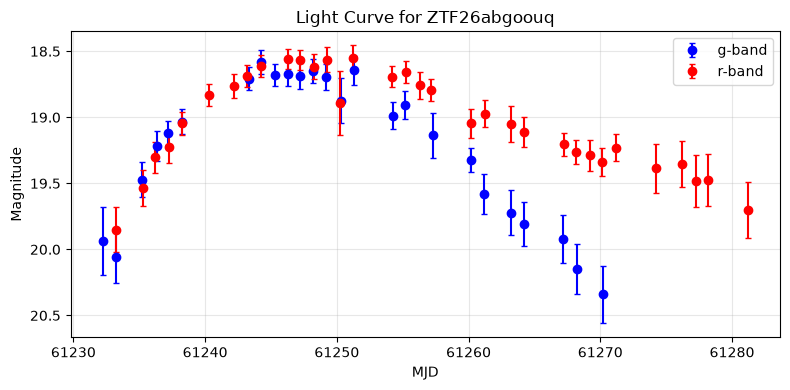

In [11]:
plt.figure(figsize=(8, 4))
for fid, color, label in [(1, 'blue', 'g-band'), (2, 'red', 'r-band')]:
    sub = df_filtered_det[df_filtered_det['fid'] == fid]
    if not sub.empty:
        plt.errorbar(sub['mjd'], sub['magpsf'], yerr=sub['sigmapsf'],
                     fmt='o', color=color, label=label, capsize=2)
plt.gca().invert_yaxis() 
plt.xlabel('MJD')
plt.ylabel('Magnitude')
plt.title(f'Light Curve for {oid}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
def evaluate_light_curve_metrics(df_det):
    """
    Calculates photometric rise rates and baseline duration for a given detection table.
    """
    df_sorted = df_det.sort_values('mjd')
    
    mjd_first = df_sorted['mjd'].min()
    mjd_last = df_sorted['mjd'].max()
    baseline_duration = mjd_last - mjd_first
    
    recent_cutoff = mjd_last - 5.0
    df_recent = df_sorted[df_sorted['mjd'] >= recent_cutoff]
    
    rise_rate = 0.0
    if len(df_recent) >= 2:
        m_1, t_1 = df_recent.iloc[0]['magpsf'], df_recent.iloc[0]['mjd']
        m_2, t_2 = df_recent.iloc[-1]['magpsf'], df_recent.iloc[-1]['mjd']
        rise_rate = (m_2 - m_1) / (t_2 - t_1)  
    
    return baseline_duration, rise_rate

[*] Analyzing Target: ZTF26abmabrc (ML P(SNIa): 0.53)
   -> Retrieved 39 multi-band detection epochs.
   -> Baseline: 34.0 d, Rise rate (last 5d): -0.0892 mag/day


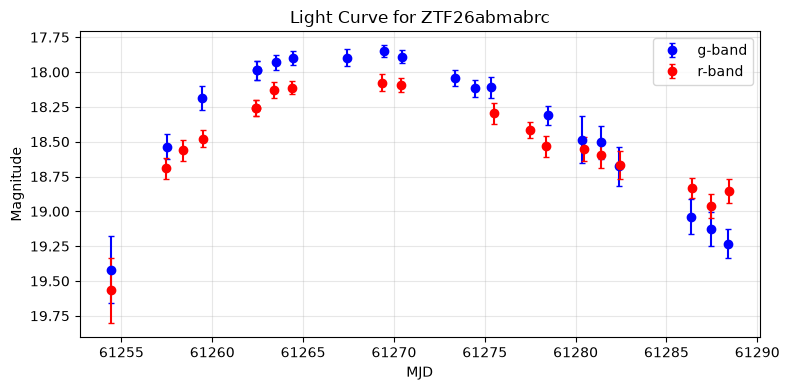

[*] Analyzing Target: ZTF26abjlpcn (ML P(SNIa): 0.51)
   -> Retrieved 100 multi-band detection epochs.
   -> Baseline: 45.0 d, Rise rate (last 5d): -0.2138 mag/day


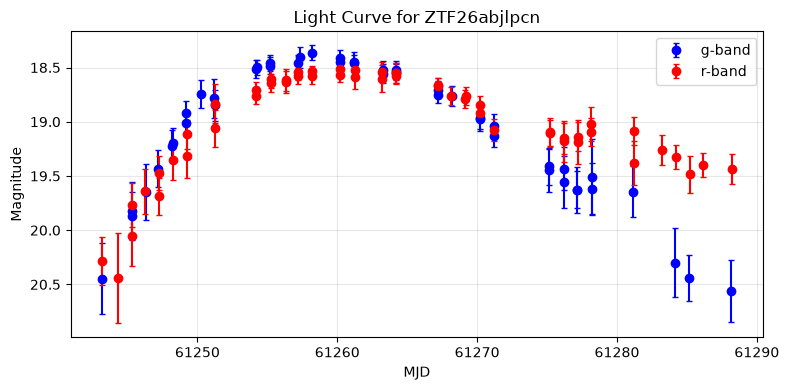

[*] Analyzing Target: ZTF26abjntai (ML P(SNIa): 0.49)
   -> Retrieved 43 multi-band detection epochs.
   -> Baseline: 42.0 d, Rise rate (last 5d): 0.0257 mag/day


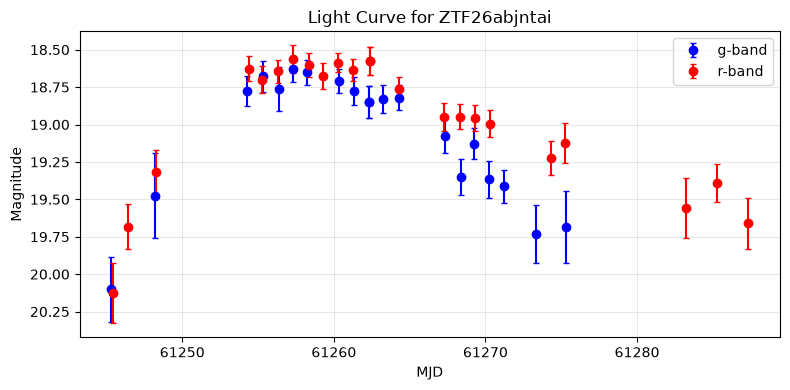

[*] Analyzing Target: ZTF26abohaoe (ML P(SNIa): 0.47)
   -> Retrieved 29 multi-band detection epochs.
   -> Baseline: 21.0 d, Rise rate (last 5d): 0.0964 mag/day


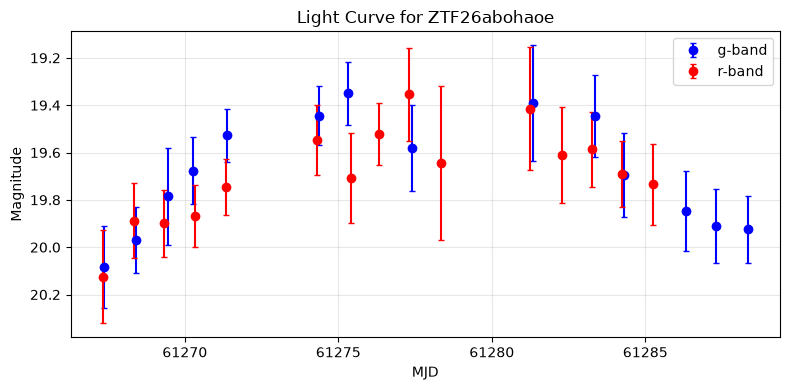

[*] Analyzing Target: ZTF26abqwczz (ML P(SNIa): 0.47)
   -> Retrieved 11 multi-band detection epochs.
   -> Baseline: 7.9 d, Rise rate (last 5d): 0.1364 mag/day


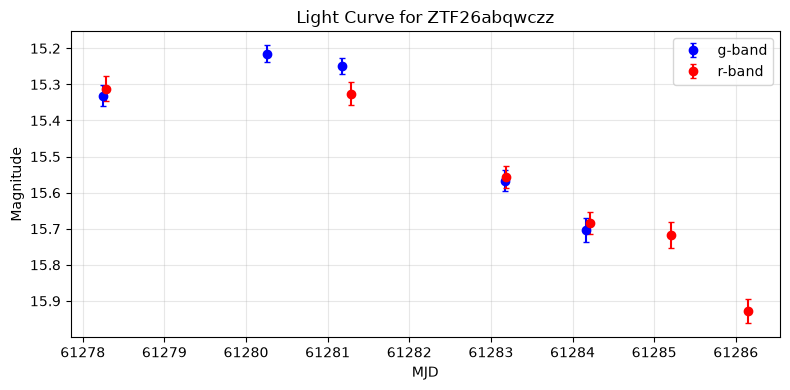

[*] Analyzing Target: ZTF26abpyrfi (ML P(SNIa): 0.46)
   -> Retrieved 18 multi-band detection epochs.
   -> Baseline: 11.0 d, Rise rate (last 5d): 0.1629 mag/day


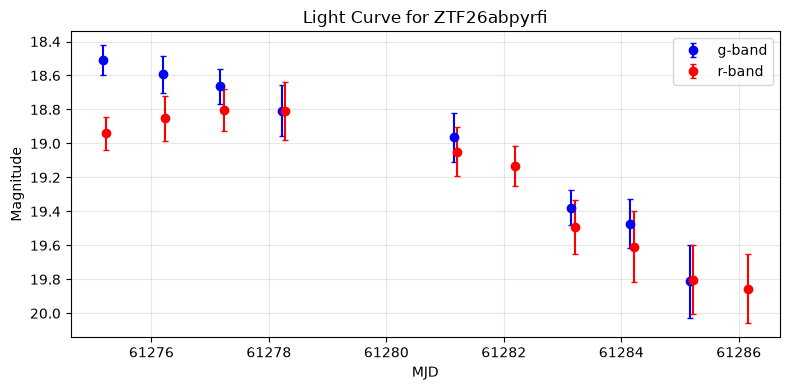

[*] Analyzing Target: ZTF26abnuiar (ML P(SNIa): 0.45)
   -> Retrieved 22 multi-band detection epochs.
   -> Baseline: 23.0 d, Rise rate (last 5d): 0.0823 mag/day


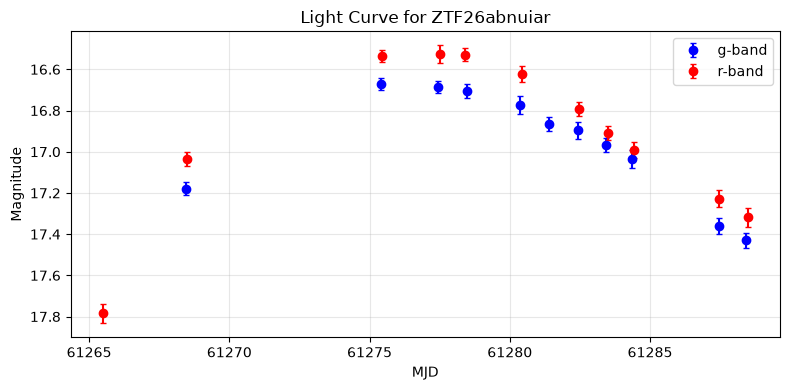

[*] Analyzing Target: ZTF26abhmgla (ML P(SNIa): 0.45)
   -> Retrieved 24 multi-band detection epochs.
   -> Baseline: 23.0 d, Rise rate (last 5d): 0.0548 mag/day


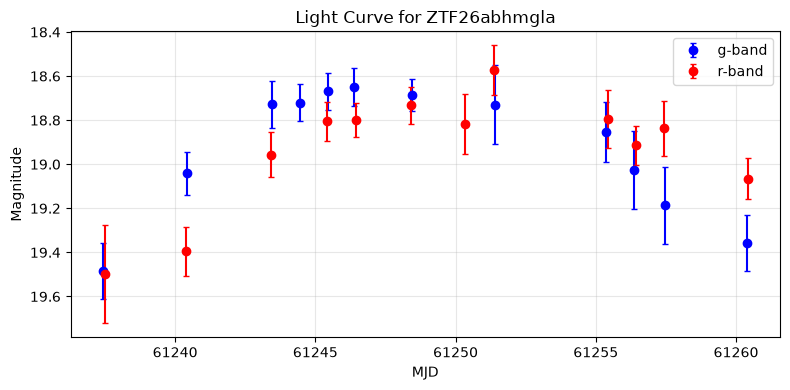

[*] Analyzing Target: ZTF26ablrszk (ML P(SNIa): 0.45)
   -> Retrieved 38 multi-band detection epochs.
   -> Baseline: 30.9 d, Rise rate (last 5d): -0.0749 mag/day


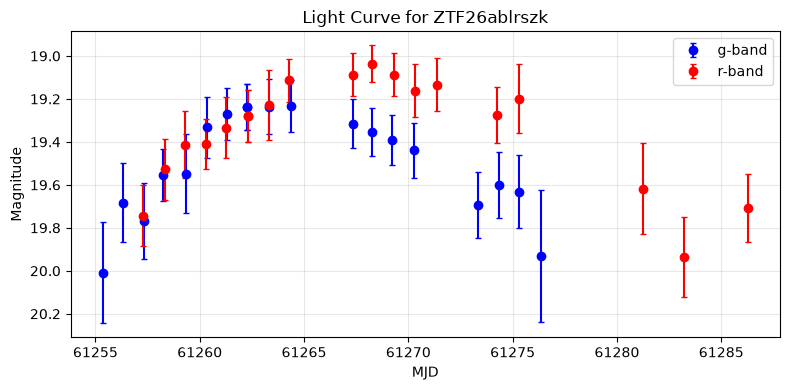

[*] Analyzing Target: ZTF26abgoouq (ML P(SNIa): 0.44)
   -> Retrieved 58 multi-band detection epochs.
   -> Baseline: 49.0 d, Rise rate (last 5d): 0.0701 mag/day


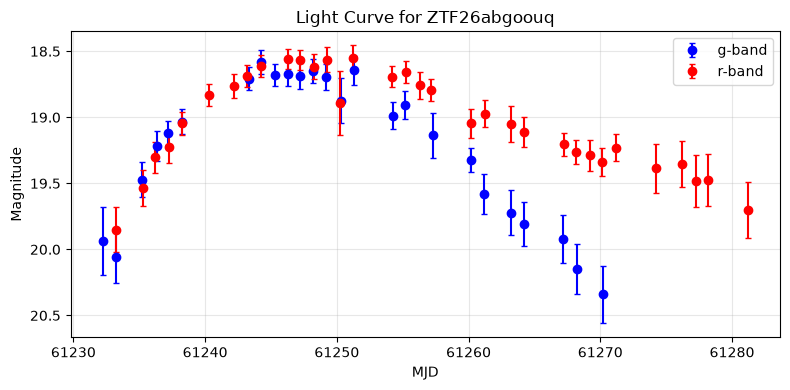

In [19]:
filtered_candidates = []

for index, row in df_alerts.iterrows():
    oid = row['oid']
    ml_prob = row['probability']
    
    print(f"[*] Analyzing Target: {oid} (ML P(SNIa): {ml_prob:.2f})")
    
    try:
        lc_data = alerce.query_lightcurve(oid)
        df_det = pd.DataFrame(lc_data['detections'])
        
        if df_det.empty:
            print(f"   -> WARNING: No detection table found for {oid}. Skipping.\n")
            continue
            
        df_filtered_det = df_det[df_det['fid'].isin([1, 2])]
        print(f"   -> Retrieved {len(df_filtered_det)} multi-band detection epochs.")

        
        if not df_filtered_det.empty:
            base_dur, r_rate = evaluate_light_curve_metrics(df_filtered_det)
            print(f"   -> Baseline: {base_dur:.1f} d, Rise rate (last 5d): {r_rate:.4f} mag/day")

        plt.figure(figsize=(8, 4))
        for fid, color, label in [(1, 'blue', 'g-band'), (2, 'red', 'r-band')]:
            sub = df_filtered_det[df_filtered_det['fid'] == fid]
            if not sub.empty:
                plt.errorbar(sub['mjd'], sub['magpsf'], yerr=sub['sigmapsf'],
                             fmt='o', color=color, label=label, capsize=2)
        plt.gca().invert_yaxis()
        plt.xlabel('MJD')
        plt.ylabel('Magnitude')
        plt.title(f'Light Curve for {oid}')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        
    except Exception as e:
        print(f"[\033[91mERROR\033[0m] Failed to fetch light curve for {oid}: {e}")

### Subtask 3: Cross-Catalog Association

1. **Coordinate Extraction:** Retrieve equatorial coordinates ($\alpha = \text{RA}$, $\delta = \text{Dec}$) in decimal degrees for each short-listed candidate.
2. **Catalog Querying:** Perform positional cross-matching against the TNS database using the helper function `cassa_tns_check(oid, ra, dec)`.
3. **Status Filtering:** Separate previously classified transients (e.g., `SN Ia`, `SN II`, `CV`) from targets flagged as `UNCLASSIFIED`. Only `UNCLASSIFIED` targets represent high-value, unobserved candidates eligible for our observing run.

In [26]:
def cassa_tns_check(oid: str, ra: float, dec: float, use_live_api: bool = True) -> bool:
    """
    Validates a candidate ZTF object against the Mock Transient Name Server (TNS).
    Returns True if UNCLASSIFIED (approved), False if classified (rejected).
    """
    print(f"[*] Transmitting {oid} [RA: {ra:.4f}, Dec: {dec:.4f}] to TNS Engine...")
    
    baseline_days = 0.0

    if use_live_api:
        try:
            stats = alerce.query_magstats(oid)
            df_stats = pd.DataFrame(stats)

            if df_stats.empty:
                print(f"  [\033[91mAPI ERROR\033[0m] No photometric statistics returned.")
                return False

            first_mjd = df_stats['firstmjd'].min()
            last_mjd = df_stats['lastmjd'].max()
            baseline_days = last_mjd - first_mjd

        except KeyError as ke:
            print(f"  [\033[91mKEY ERROR\033[0m] Invalid column name in DataFrame: {ke}")
            return False
        except Exception as e:
            print(f"  [\033[91mCONNECTION ERROR\033[0m] Server unreachable: {e}")
            return False
            
    else:
        pass 

    # Triage Logic: Reject anything with a baseline > 100 days
    if baseline_days > 100:
        print(f"  [\033[91mREJECTED\033[0m] Cross-match found in TNS/SIMBAD archives.")
        print(f"     -> Baseline: {baseline_days:.1f} days. Classification: AGN/Variable.")
        return False
    else:
        print(f"  [\033[92mAPPROVED\033[0m] No matches found in global catalogs.")
        print(f"     -> Baseline: {baseline_days:.1f} days. Classification: UNCLASSIFIED.")
        return True

In [27]:
lco_ready_targets = []

for index, row in df_alerts.iterrows():
    candidate_oid = row['oid']
    
    try:
        obj_data = alerce.query_object(candidate_oid)
        ra = obj_data['meanra']
        dec = obj_data['meandec']
        
        is_unclassified = cassa_tns_check(candidate_oid, ra, dec, use_live_api=True)
        
        if is_unclassified:
            lco_ready_targets.append({
                'oid': candidate_oid,
                'ra': ra,
                'dec': dec,
                'ml_probability': row['probability']
            })
            
    except Exception as e:
        print(f"  [\033[91mPIPELINE ERROR\033[0m] Failed to process {candidate_oid}: {e}")
        
    print("-" * 50)

print(f"PIPELINE COMPLETE: {len(lco_ready_targets)} TARGET(S) APPROVED FOR OBSERVATION")

# Convert the final list to a DataFrame for clean visualization and export
if len(lco_ready_targets) > 0:
    df_final_payload = pd.DataFrame(lco_ready_targets)
    display(df_final_payload)
else:
    print("WARNING: All targets were rejected by the pipeline. Broaden your search criteria.")

[*] Transmitting ZTF26abmabrc [RA: 25.6432, Dec: -2.8236] to TNS Engine...
  [APPROVED] No matches found in global catalogs.
     -> Baseline: 34.0 days. Classification: UNCLASSIFIED.
--------------------------------------------------
[*] Transmitting ZTF26abjlpcn [RA: 250.3586, Dec: 3.9739] to TNS Engine...
  [APPROVED] No matches found in global catalogs.
     -> Baseline: 45.0 days. Classification: UNCLASSIFIED.
--------------------------------------------------
[*] Transmitting ZTF26abjntai [RA: 310.4084, Dec: -18.5838] to TNS Engine...
  [APPROVED] No matches found in global catalogs.
     -> Baseline: 42.0 days. Classification: UNCLASSIFIED.
--------------------------------------------------
[*] Transmitting ZTF26abohaoe [RA: 327.1716, Dec: 1.5483] to TNS Engine...
  [APPROVED] No matches found in global catalogs.
     -> Baseline: 21.0 days. Classification: UNCLASSIFIED.
--------------------------------------------------
[*] Transmitting ZTF26abqwczz [RA: 275.5385, Dec: -14.9431

,oid,ra,dec,ml_probability
0,ZTF26abmabrc,25.643162,-2.823642,0.528940
1,ZTF26abjlpcn,250.358637,3.973885,0.514968
2,ZTF26abjntai,310.408360,-18.583786,0.488000
3,ZTF26abohaoe,327.171594,1.548332,0.469300
4,ZTF26abqwczz,275.538463,-14.943093,0.466576
5,ZTF26abpyrfi,262.390771,15.405061,0.463072
6,ZTF26abnuiar,47.074983,11.913260,0.454152
7,ZTF26abhmgla,354.328716,-9.109913,0.448704
8,ZTF26ablrszk,309.601515,-3.188181,0.448384
9,ZTF26abgoouq,250.423820,10.243507,0.443520


## Subtask 4: Target Observability

Must ensure our chosen target physically rises high enough above the horizon to minimize atmospheric distortion. Furthermore, must calculate the exact photon statistics required to secure a high-fidelity classification spectrum.

1. Map the airmass trajectory $X(t)$ across the night for personal top-ranked candidate from the Cerro Tololo ($\text{CTIO}$) site. Verify that $X(t) \le 1.5$.
2. Compute the precise exposure time using Equation (4) in the questionnaire.
3. Format the target attributes into a standard JSON observation payload and execute `submit_lco_trigger(payload)`.

In [36]:
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
import astropy.units as u
import numpy as np

if 'df_final_payload' in locals() and not df_final_payload.empty:
    target_row = df_final_payload.iloc[0]
    target_oid = target_row['oid']
    ra_deg = target_row['ra']
    dec_deg = target_row['dec']
    ml_prob = target_row['ml_probability']
    print(f"[*] Selected Target for Payload: {target_oid} (ML P(SNIa): {ml_prob:.2f})")
else:
    target_oid = 'ZTF26abmabrc'
    ra_deg, dec_deg = 25.6432, -2.8236
    print(f"[*] Using fallback target: {target_oid}")

ctio_location = EarthLocation.of_site('ctio')

target_coord = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame='icrs')

observe_times = Time.now() + np.linspace(0, 10, 100) * u.hour
altaz_frame = AltAz(obstime=observe_times, location=ctio_location)

target_altaz = target_coord.transform_to(altaz_frame)
airmass_array = target_altaz.secz

valid_airmasses = airmass_array[airmass_array > 0]
min_airmass = valid_airmasses.min() if len(valid_airmasses) > 0 else 99.0

print(f"[*] Computed Minimum Airmass from CTIO: {min_airmass:.2f}")

if min_airmass <= 1.5:
    print("  -> [\033[92mPASS\033[0m] Target reaches optimal airmass threshold (X <= 1.5).")
else:
    print("  -> [\033[91mFAIL\033[0m] Target remains too low on the horizon.")

[*] Selected Target for Payload: ZTF26abmabrc (ML P(SNIa): 0.53)
[*] Computed Minimum Airmass from CTIO: 3.15
  -> [FAIL] Target remains too low on the horizon.


In [37]:
import importlib
import observability
importlib.reload(observability)

from observability import submit_lco_trigger

In [38]:
t_0 = 300.0     # Reference exposure time (in seconds)
m_0 = 18.0      # Reference apparent magnitude
snr_0 = 10.0    # Reference Signal-to-Noise Ratio

# Target parameters (Estimated current apparent r-band magnitude for our target)
target_mag = 18.2 
required_snr = 12.0

# Calculate required exposure time
mag_diff_factor = 10 ** (0.4 * (target_mag - m_0))
snr_factor = (required_snr / snr_0) ** 2
calculated_t_exp = t_0 * mag_diff_factor * snr_factor

print(f"[*] Calculated Exposure Time: {calculated_t_exp:.1f} seconds for Magnitude {target_mag}")

# Construct the standard LCO Observation Portal JSON payload schema
lco_payload = {
    "Target": {
        "Name": target_oid,
        "RA": ra_deg,
        "Dec": dec_deg,
        "Magnitude": target_mag
    },
    "Constraints": {
        "Max_Airmass": 1.5,
        "Required_SNR": required_snr
    },
    "Instrument": {
        "Telescope": "2-meter",
        "Spectrograph": "FLOYDS",
        "Exposure_Time": round(calculated_t_exp, 1)
    }
}

# Submit payload to the local observability validation backend
print("\n" + "="*50)
print("SUBMITTING PAYLOAD TO OBSERVATION PORTAL")
print("="*50)
submit_lco_trigger(lco_payload)

[*] Calculated Exposure Time: 519.4 seconds for Magnitude 18.2

SUBMITTING PAYLOAD TO OBSERVATION PORTAL
Initiating LCO Observation Portal API Handshake...

[200 OK] Payload accepted by LCO Observation Portal.
[INFO] Calculating ephemerides and scheduling observation on 2m0a (Cerro Tololo).
[SUCCESS] Telescope slewing to target. Dome opening...
      -> Target: ZTF26abmabrc
      -> Expected SNR: ~12.0 in 519.4 seconds.


True

## Multi-Band Light Curve Verification

[*] Querying detection history for ZTF26abmabrc (Attempt 1/3)...


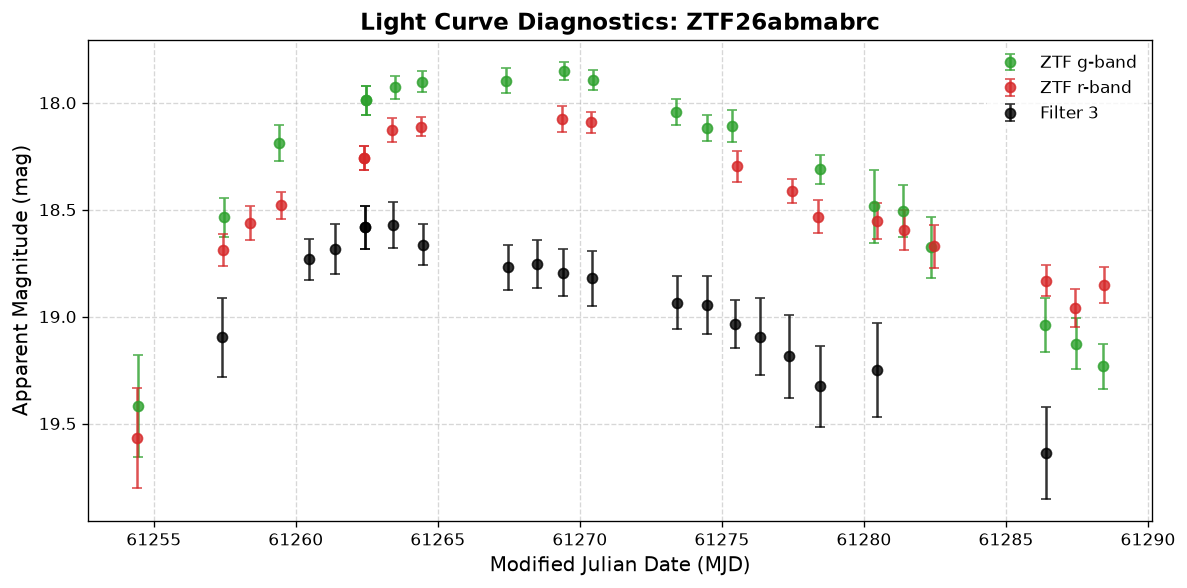

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import time
import os

max_retries = 3
df_dets = pd.DataFrame()

for attempt in range(max_retries):
    try:
        print(f"[*] Querying detection history for {target_oid} (Attempt {attempt + 1}/{max_retries})...")
        df_dets = alerce.query_detections(oid=target_oid, survey="ztf", format="pandas")
        if not df_dets.empty:
            break
    except Exception as e:
        print(f"  [\033[93mWARNING\033[0m] Connection dropped: {e}")
        if attempt < max_retries - 1:
            print("  Retrying in 2 seconds...")
            time.sleep(2)
        else:
            print("  [\033[91mAPI ERROR\033[0m] Live server unreachable after multiple attempts.")

if df_dets.empty:
    print("[*] Switching to local reference fallback data...")
    parquet_path = os.path.join("data", "reference_alerts.parquet")
    if not os.path.exists(parquet_path):
        parquet_path = os.path.join("..", "data", "reference_alerts.parquet")
        
    try:
        df_all = pd.read_parquet(parquet_path)
        print("  [\033[92mSUCCESS\033[0m] Loaded offline cache successfully.")
    except Exception as err:
        print(f"  [\033[91mFATAL ERROR\033[0m] Could not load offline fallback: {err}")

if not df_dets.empty:
    df_dets = df_dets.sort_values('mjd')
    
    plt.figure(figsize=(10, 5), dpi=120)
    
    band_colors = {1: '#2ca02c', 2: '#d62728'} # 1: g-band (green), 2: r-band (red)
    band_names = {1: 'ZTF g-band', 2: 'ZTF r-band'}
    
    for fid, group in df_dets.groupby('fid'):
        plt.errorbar(
            group['mjd'], 
            group['magpsf'], 
            yerr=group['sigmapsf'],
            fmt='o', 
            color=band_colors.get(fid, 'k'), 
            label=band_names.get(fid, f'Filter {fid}'),
            alpha=0.8,
            capsize=3
        )
        
    plt.gca().invert_yaxis() # Astronomers plot magnitude upside down (brighter = top)
    plt.xlabel('Modified Julian Date (MJD)', fontsize=12)
    plt.ylabel('Apparent Magnitude (mag)', fontsize=12)
    plt.title(f'Light Curve Diagnostics: {target_oid}', fontsize=14, fontweight='bold')
    plt.legend(frameon=True, facecolor='white', edgecolor='none')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("[\033[91mERROR\033[0m] Unable to render light curve: No detection data could be fetched.")